In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from lifelines import AalenJohansenFitter

# ==========================================
# 0. Configuration
# ==========================================
AIDEV_REVISION = "68ed5f4"
DATASET_CUTOFF = pd.Timestamp("2025-08-01 23:59:59", tz = "UTC")

target_agents = ["Human", "OpenAI_Codex", "Claude_Code", "Copilot", "Cursor", "Devin"]

ADMIN_WINDOW_DAYS = 60
INSTANT_MERGE_CUTOFF_DAYS = 1/1440

In [25]:
# ==========================================
# 1. Load data & align to a common repository cohort
# ==========================================
df_ai_raw = load_dataset(
    "hao-li/AIDev",
    "pull_request",
    split = "train",
    revision = AIDEV_REVISION
).to_pandas()

df_human_raw = load_dataset(
    "hao-li/AIDev",
    "human_pull_request",
    split = "train",
    revision = AIDEV_REVISION
).to_pandas()

df_human_raw["agent"] = "Human"

ai_repos = set(df_ai_raw["repo_url"].dropna())
human_repos = set(df_human_raw["repo_url"].dropna())
common_repos = ai_repos & human_repos

df_ai_filtered = df_ai_raw[df_ai_raw["repo_url"].isin(common_repos)].copy()
df_human_filtered = df_human_raw[df_human_raw["repo_url"].isin(common_repos)].copy()
df = pd.concat([df_ai_filtered, df_human_filtered], ignore_index=True)

df_valid = df[df["agent"].isin(target_agents)].copy()

In [26]:
# ==========================================
# 2. Define competing-risk events with administrative censoring
# ==========================================
time_cols = ["created_at", "merged_at", "closed_at"]
df_valid[time_cols] = df_valid[time_cols].apply(pd.to_datetime, errors="coerce", utc=True)

df_valid = df_valid[
    (df_valid["created_at"].notna())
    & (df_valid["created_at"] <= DATASET_CUTOFF)
].copy()

df_valid["admin_end"] = (
    df_valid["created_at"] + pd.Timedelta(days=ADMIN_WINDOW_DAYS)
).clip(upper=DATASET_CUTOFF)

df_valid["status_code"] = 0

mask_merge = (
    (df_valid["merged_at"].notna())
    & (df_valid["merged_at"] <= df_valid["admin_end"])
)
df_valid.loc[mask_merge, "status_code"] = 1

mask_close = (
    (df_valid["merged_at"].isna())
    & (df_valid["closed_at"].notna())
    & (df_valid["closed_at"] <= df_valid["admin_end"])
)
df_valid.loc[mask_close, "status_code"] = 2

assert df_valid["created_at"].notna().all(), "Found PR without created_at timestamp"
assert df_valid["admin_end"].notna().all(), "Found PR without admin_end computed"
assert set(df_valid["status_code"].unique()) <= {0, 1, 2}, "Unexpected status_code value"

df_valid["obs_end"] = df_valid["admin_end"]
df_valid.loc[mask_merge, "obs_end"] = df_valid.loc[mask_merge, "merged_at"]
df_valid.loc[mask_close, "obs_end"] = df_valid.loc[mask_close, "closed_at"]

df_valid["lag_days"] = (
    df_valid["obs_end"] - df_valid["created_at"]
).dt.total_seconds() / 86400.0
assert df_valid["lag_days"].between(0, ADMIN_WINDOW_DAYS).all(), "unexpected lag_days"

In [27]:
# ==========================================
# 3. Sensitivity cohort: strip out sub-1-minute "instant" merges
# ==========================================
df_main = df_valid.copy()

mask_instant_merge = (
    (df_valid["status_code"] == 1)
    & (df_valid["lag_days"] < INSTANT_MERGE_CUTOFF_DAYS)
)
df_sensitivity = df_valid[~mask_instant_merge].copy()

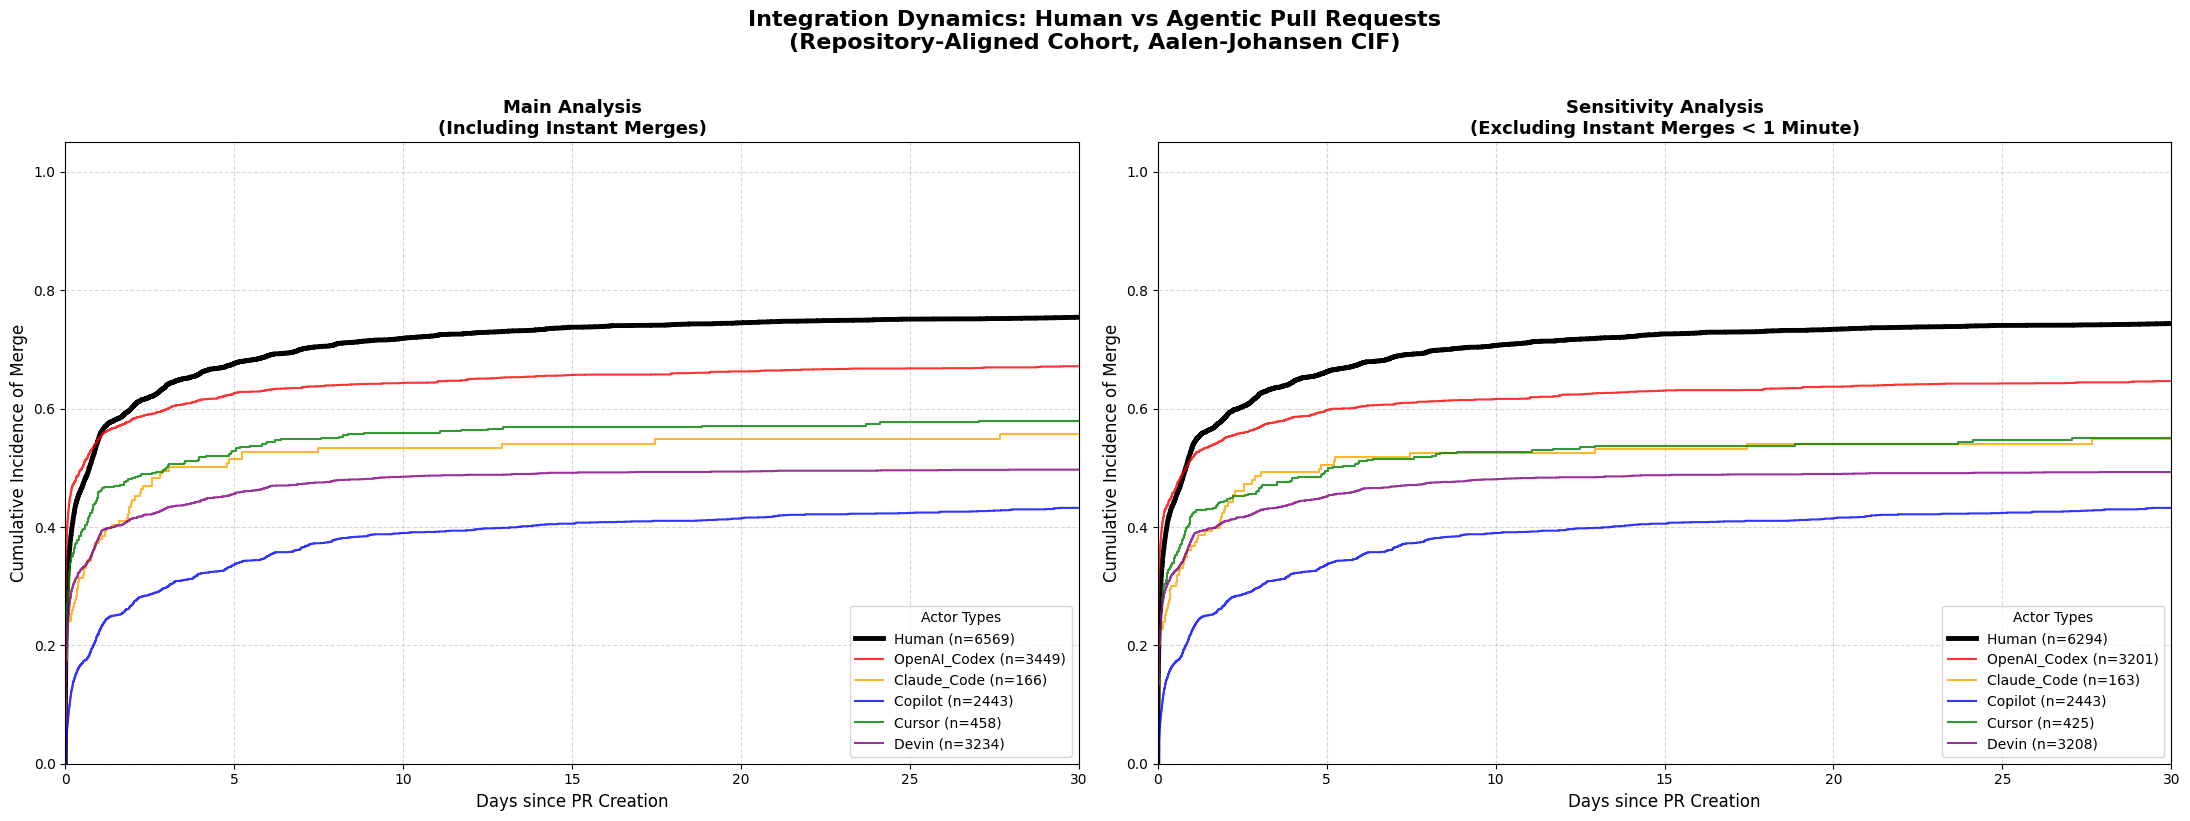

In [28]:
# ==========================================
# 4. Fit Aalen-Johansen CIF per agent and plot main + sensitivity panels
# ==========================================
aj_fitter = AalenJohansenFitter(calculate_variance=True, seed=42)

color_map = {
    "Human": "black", "OpenAI_Codex": "red", "Claude_Code": "orange",
    "Copilot": "blue", "Cursor": "green", "Devin": "purple",
}

def plot_cohort(cohort_df, ax, title):
    for agent in target_agents:
        agent_data = cohort_df[cohort_df["agent"] == agent]
        if len(agent_data) == 0:
            continue
        aj_fitter.fit(
            durations = agent_data["lag_days"],
            event_observed = agent_data["status_code"],
            event_of_interest = 1,
        )
        is_human = agent == "Human"
        aj_fitter.plot(
            label=f"{agent} (n={len(agent_data)})",
            color=color_map.get(agent, "grey"),
            linewidth=3.5 if is_human else 1.5,
            alpha=1.0 if is_human else 0.8,
            ci_show=False,
            ax=ax,
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Days since PR Creation", fontsize=12)
    ax.set_ylabel("Cumulative Incidence of Merge", fontsize=12)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(title="Actor Types", loc="lower right")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
plot_cohort(df_main, ax1, "Main Analysis\n(Including Instant Merges)")
plot_cohort(df_sensitivity, ax2, "Sensitivity Analysis\n(Excluding Instant Merges < 1 Minute)")

plt.suptitle(
    "Integration Dynamics: Human vs Agentic Pull Requests\n"
    "(Repository-Aligned Cohort, Aalen-Johansen CIF)",
    fontsize=16, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("Aalen_Johansen_CIF.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
event_summary = (
    df_valid
    .groupby(["agent", "status_code"])
    .size()
    .unstack(fill_value=0)
)

print(event_summary)

status_code     0     1     2
agent                        
Claude_Code    26    91    49
Copilot       512  1064   867
Cursor         61   265   132
Devin         117  1607  1510
Human         545  5015  1009
OpenAI_Codex  270  2326   853
